In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from database.adatabase import ADatabase
import matplotlib.dates as mdates

market = ADatabase("market")

C:\Users\eric\AppData\Local\Temp\ipykernel_16856\2889019176.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['signal'][df['adjclose'] > df['upper_band']] = 1  # -1 means sell/short
C:\Users\eric\AppData\Local\Temp\ipykernel_16856\2889019176.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['signal'][df['adjclose'] < df['lower_band']] = -1  # 1 means buy/long


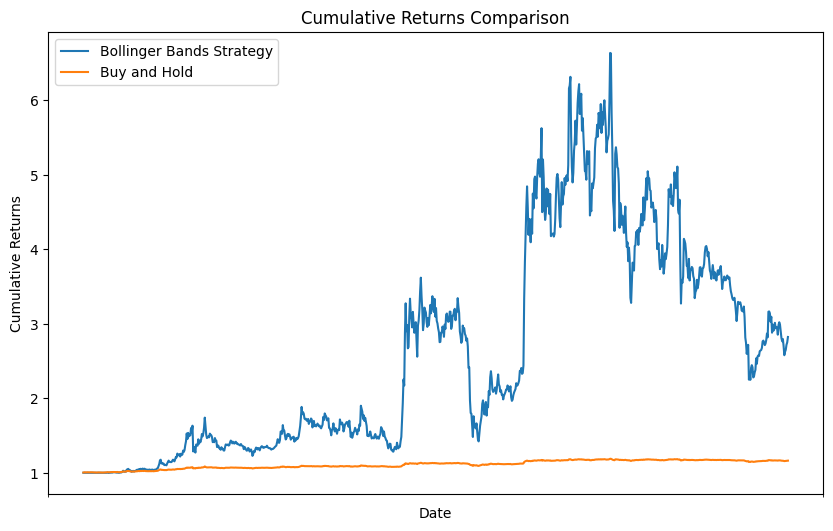

In [5]:
market = ADatabase("market")
market.connect()
df = market.retrieve("crypto").sort_values("date").set_index("date")
market.disconnect()
df.index = pd.to_datetime(df.index)

# Calculate the rolling mean and standard deviation
window = 10  # You can adjust this value based on your strategy
df['rolling_mean'] = df['adjclose'].rolling(window=window).mean()
df['upper_band'] = df['rolling_mean'] + 2 * df['adjclose'].rolling(window=window).std()
df['lower_band'] = df['rolling_mean'] - 2 * df['adjclose'].rolling(window=window).std()

# Create signals based on the modified strategy with stop-loss and take-profit
df['signal'] = 0  # 0 means no signal

# Sell signal: Price touches above upper Bollinger Band
df['signal'][df['adjclose'] > df['upper_band']] = 1  # -1 means sell/short

# Buy signal: Price touches below lower Bollinger Band
df['signal'][df['adjclose'] < df['lower_band']] = -1  # 1 means buy/long

# Calculate daily returns
df['daily_returns'] = df['adjclose'].pct_change()

# Apply the strategy to calculate position changes
df['position'] = df['signal'].cumsum()

# Calculate the final returns
df['strategy_returns'] = df['position'].shift(1) * df['daily_returns']

# Cumulative returns of the strategy
df['cumulative_strategy_returns'] = (1 + df['strategy_returns']).cumprod()

# Cumulative returns of holding the asset without the strategy
df['cumulative_buy_and_hold_returns'] = (1 + df['daily_returns']).cumprod()

# Convert the index to datetime format
df.index = pd.to_datetime(df.index)

# Plot cumulative returns with formatted date labels
plt.figure(figsize=(10, 6))
plt.plot(df['cumulative_strategy_returns'], label='Bollinger Bands Strategy')
plt.plot(df['cumulative_buy_and_hold_returns'], label='Buy and Hold')

# Format date labels
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator())

plt.title('Cumulative Returns Comparison')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()


In [6]:
df

,adjclose,ticker,rolling_mean,upper_band,lower_band,signal,daily_returns,position,strategy_returns,cumulative_strategy_returns,cumulative_buy_and_hold_returns
date,,,,,,,,,,,
2024-02-08 00:00:00+00:00,44353.0225,BTC/USD,NaN,NaN,NaN,0,NaN,0,NaN,NaN,NaN
2024-02-08 00:15:00+00:00,44506.8345,BTC/USD,NaN,NaN,NaN,0,0.003468,0,0.000000,1.000000,1.003468
2024-02-08 00:30:00+00:00,44565.9225,BTC/USD,NaN,NaN,NaN,0,0.001328,0,0.000000,1.000000,1.004800
2024-02-08 00:45:00+00:00,44674.0520,BTC/USD,NaN,NaN,NaN,0,0.002426,0,0.000000,1.000000,1.007238
2024-02-08 01:00:00+00:00,44551.0030,BTC/USD,NaN,NaN,NaN,0,-0.002754,0,-0.000000,1.000000,1.004464
...,...,...,...,...,...,...,...,...,...,...,...
2024-02-18 03:00:00+00:00,51352.3750,BTC/USD,51547.58675,51859.063479,51236.110021,0,0.000964,18,0.017357,2.622077,1.157810
2024-02-18 03:15:00+00:00,51382.5100,BTC/USD,51514.52625,51817.995603,51211.056897,0,0.000587,18,0.010563,2.649773,1.158489
2024-02-18 03:30:00+00:00,51455.6265,BTC/USD,51485.24095,51741.165833,51229.316067,0,0.001423,18,0.025614,2.717644,1.160138
